# Overall Distribution of Privacy Metrics

Analyzes the ecosystem-level distributions of ADII, DGI, PCLR, and AS.

# Common setup and data preparation

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

metrics_results = Path("../data/mhealth_apps_metrics.csv")
if not metrics_results.exists():
    raise FileNotFoundError(
        "Could not find `mhealth_apps_metrics.csv` in the notebook folder or at ../data/."
    )
    
REGION_MAP = {
    "us": "North America", "ca": "North America", "gl":"North America",
    "mx": "Latin America", "br": "Latin America", "ar": "Latin America", 
    "cl": "Latin America",
    "de": "Europe", "fr": "Europe", "gb": "Europe", 
    "pl": "Europe",
    "tr": "Middle East", "il": "Middle East", "sa": "Middle East", 
    "ae": "Middle East",
    "in": "Asia", "jp": "Asia", "sg": "Asia", 
    "kr": "Asia",
    "za": "Africa", "mz": "Africa", "ng": "Africa", 
    "ke": "Africa",
    "au": "Oceania", "nz": "Oceania", 
    "pg": "Oceania"
}

COUNTRY_LABEL_MAP = {
    "us": "United States", "ca": "Canada", "gl":"Greenland",
    "mx": "Mexico", "br": "Brazil", "ar": "Argentina",
    "cl": "Chile",
    "de": "Germany", "fr": "France", "gb": "Great Britain",
    "pl": "Poland",
    "tr": "Turkey", "il": "Israel", "sa": "Saudi Arabia",
    "ae": "United Arab Emirates",
    "in": "India", "jp": "Japan", "sg": "Singapore",
    "kr": "South Korea",
    "za": "South Africa", "mz": "Mozambique", "ng": "Nigeria",
    "ke": "Kenya",
    "au": "Australia", "nz": "New Zealand",
    "pg": "Papua New Guinea"
}

REGION_ORDER = [
    "North America", "Latin America", "Europe",
    "Middle East", "Asia", "Africa", "Oceania"
]

region_palette = plt.cm.tab10(np.linspace(0, 1, len(REGION_ORDER)))
REGION_COLORS = {region: region_palette[i] for i, region in enumerate(REGION_ORDER)}
category_palette = plt.cm.tab20(np.linspace(0, 1, 20))


In [26]:
import pandas as pd

df = pd.read_csv(metrics_results, low_memory=False)
print("Raw shape:", df.shape)

required_metrics = ["ADII", "DGI", "PCLR", "AS"]
missing_required = [c for c in required_metrics if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required metric columns: {missing_required}")

analysis_df = df.copy()

print("Analysis shape:", analysis_df.shape)
print("Unique apps:", analysis_df["app_id"].nunique())

display_cols = [
    "app_id", "country", "country_label", "region", "category",
    "ADII", "DGI", "PCLR", "AS",
    "observed_count", "disclosed_count", "missing_count", "misleading_count"
]
display_cols = [c for c in display_cols if c in analysis_df.columns]

Raw shape: (23392, 134)
Analysis shape: (23392, 134)
Unique apps: 931


In [27]:
print("Before shape:", df.shape)
print("After shape:", analysis_df.shape)

# Unique app counts per country
country_app_counts = (
    analysis_df.groupby(["region", "country_label"])["app_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="unique_app_count")
)

# country_app_counts

Before shape: (23392, 134)
After shape: (23392, 134)


In [28]:

summary = pd.DataFrame({
    "non_null": analysis_df[["ADII", "DGI", "PCLR", "AS"]].notna().sum(),
    "mean": analysis_df[["ADII", "DGI", "PCLR", "AS"]].mean(),
    "median": analysis_df[["ADII", "DGI", "PCLR", "AS"]].median(),
    "std": analysis_df[["ADII", "DGI", "PCLR", "AS"]].std(),
    "min": analysis_df[["ADII", "DGI", "PCLR", "AS"]].min(),
    "max": analysis_df[["ADII", "DGI", "PCLR", "AS"]].max(),
}).round(4)
summary


,non_null,mean,median,std,min,max
ADII,23392,189.0859,100.0000,323.8028,7.0000,12935.0000
DGI,23392,0.2559,0.0000,0.3968,0.0000,1.0000
PCLR,11967,0.3063,0.2000,0.3386,0.0000,1.0000
AS,23383,0.3787,0.3761,0.0924,0.1064,0.7473


In [29]:

country_level = analysis_df.copy()

metric_agg = {
    "ADII": "mean",
    "DGI": "mean",
    "PCLR": "mean",
    "AS": "mean",
}

meta_agg = {
    "country_label": "nunique",
    "region": lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan,
    "category": lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan,
    "num_permissions": "mean",
    "num_dangerous_permissions": "mean",
    "num_trackers": "mean",
    "downloads_int": "mean",
    "average_score": "mean",
}

agg_dict = {}
for k, v in {**metric_agg, **meta_agg}.items():
    if k in analysis_df.columns:
        agg_dict[k] = v

app_level = analysis_df.groupby("app_id", as_index=False).agg(agg_dict)
app_level = app_level.rename(columns={"country_label": "country_count"})
app_level_all = app_level.copy()

if "PCLR" not in app_level_all.columns:
    if "app_country_PCLR" in analysis_df.columns:
        pclr_fallback = (
            analysis_df.groupby("app_id", as_index=False)["app_country_PCLR"]
            .mean()
            .rename(columns={"app_country_PCLR": "PCLR"})
        )
        app_level_all = app_level_all.merge(pclr_fallback, on="app_id", how="left")
    elif {"app_country_pre_sensitive_instances", "app_country_total_sensitive_instances"}.issubset(analysis_df.columns):
        pclr_fallback = (
            analysis_df.groupby("app_id", as_index=False)[
                ["app_country_pre_sensitive_instances", "app_country_total_sensitive_instances"]
            ]
            .mean()
        )
        denom = pclr_fallback["app_country_total_sensitive_instances"].replace(0, np.nan)
        pclr_fallback["PCLR"] = pclr_fallback["app_country_pre_sensitive_instances"] / denom
        app_level_all = app_level_all.merge(pclr_fallback[["app_id", "PCLR"]], on="app_id", how="left")

print("Country-level rows:", len(country_level))
print("App-level rows:", len(app_level_all))
print("App-level metric columns:", [c for c in ["ADII", "DGI", "PCLR", "AS"] if c in app_level_all.columns])
app_level = app_level_all.copy()



Country-level rows: 23392
App-level rows: 931
App-level metric columns: ['ADII', 'DGI', 'PCLR', 'AS']



## Figure 1 — Metric distributions across all observations

This multi-panel histogram view shows the overall distribution of the four privacy metrics.


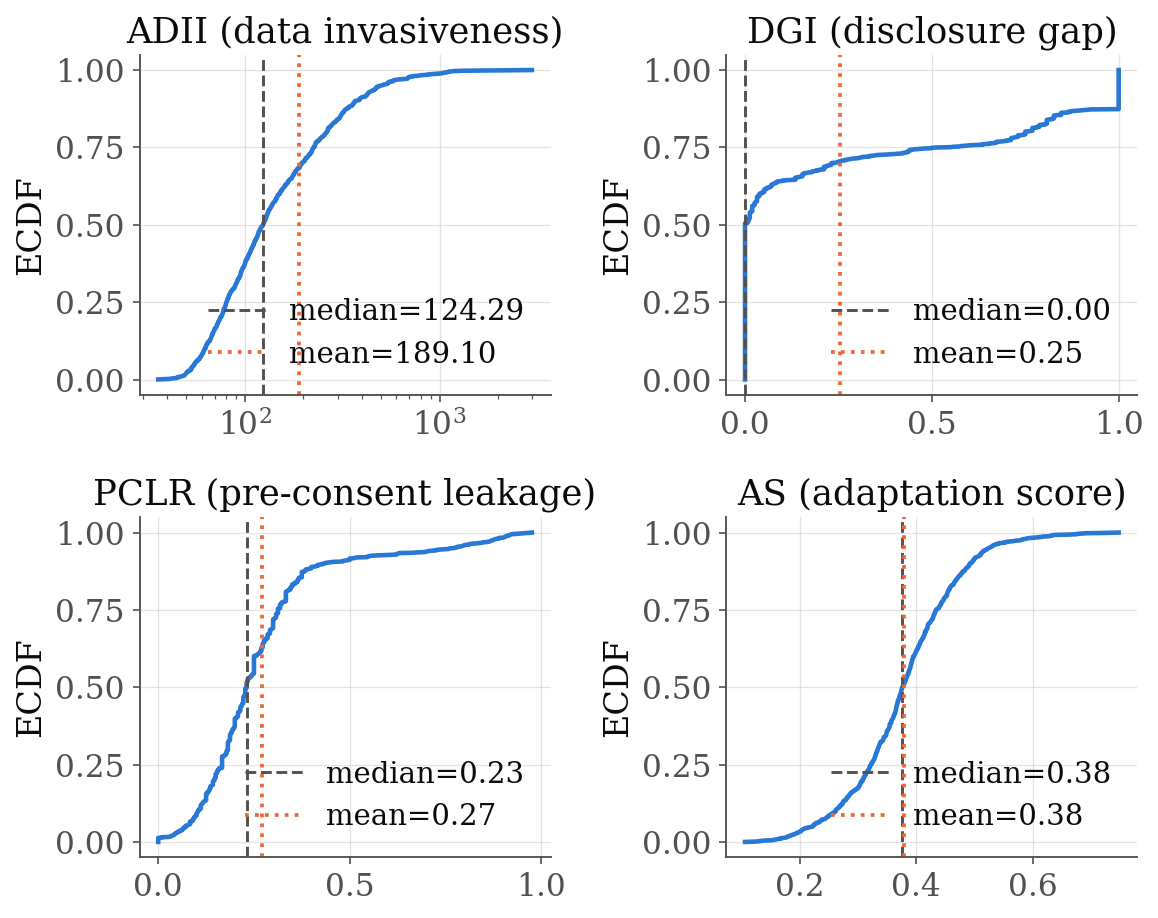

Saved figure to: ../figures/ecdf_privacy_metrics.pdf (N=920)


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("../figures")
output_dir.mkdir(parents=True, exist_ok=True)

CATV = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID_COLOR = "#d9d8d3"

plt.rcParams.update({
    "font.size": 16,
    "font.family": "serif",
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.edgecolor": TEXT_SECONDARY,
    "axes.labelcolor": TEXT_PRIMARY,
    "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "lines.linewidth": 1.8,
    "pdf.fonttype": 42,
    "figure.dpi": 150,
})

complete = app_level_all.dropna(subset=["ADII", "DGI", "PCLR", "AS"])

metrics = [("ADII", "ADII (data invasiveness)"), ("DGI", "DGI (disclosure gap)"),
           ("PCLR", "PCLR (pre-consent leakage)"), ("AS", "AS (adaptation score)")]

fig, axes = plt.subplots(2, 2, figsize=(8.0, 6.4))
for ax, (metric, label) in zip(axes.flat, metrics):
    if metric not in complete.columns:
        ax.axis("off")
        ax.set_title(f"{label} (missing)")
        continue

    values = pd.to_numeric(complete[metric], errors="coerce").dropna().sort_values().to_numpy()
    if len(values) == 0:
        ax.axis("off")
        ax.set_title(f"{label} (no data)")
        continue

    y = np.arange(1, len(values) + 1) / len(values)
    ax.plot(values, y, color=CATV[0], linewidth=2.2)

    med, mean = np.median(values), np.mean(values)
    ax.axvline(med, color=TEXT_SECONDARY, linestyle="--", linewidth=1.4, label=f"median={med:.2f}")
    ax.axvline(mean, color=CATV[1], linestyle=":", linewidth=1.8, label=f"mean={mean:.2f}")

    ax.set_title(label)
    ax.set_ylabel("ECDF")
    ax.legend(loc="lower right", frameon=False, fontsize=14)

    if metric == "ADII":
        ax.set_xscale("log")

fig.tight_layout()
save_path = output_dir / "ecdf_privacy_metrics.pdf"
fig.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved figure to: {save_path} (N={len(complete)})")